In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn import svm
from sklearn import tree
from yellowbrick.classifier import ROCAUC

In [2]:
data=pd.read_csv("balanced_ecoli_rand.csv")

In [3]:
data

,Unnamed: 0,Class,mcg,gvh,lip,chg,aac,alm1,alm2
0,0,3,0.78,0.33,0.48,0.5,0.57,0.77,0.79
1,1,1,0.25,0.37,0.48,0.5,0.43,0.26,0.36
2,2,2,0.44,0.52,0.48,0.5,0.43,0.47,0.54
3,3,4,0.65,0.51,0.48,0.5,0.66,0.54,0.33
4,4,5,0.64,0.84,0.48,0.5,0.37,0.45,0.40
...,...,...,...,...,...,...,...,...,...
400,400,3,0.64,0.45,0.48,0.5,0.67,0.61,0.66
401,401,4,0.68,0.76,0.48,0.5,0.84,0.45,0.27
402,402,3,0.49,0.61,1.00,0.5,0.56,0.71,0.74
403,403,5,0.73,0.78,0.48,0.5,0.58,0.51,0.31


In [4]:
data.columns=['id','Class','mcg','gvh','lip','chg','aac','alm1','alm2']

In [5]:
data.set_index("id", inplace=True)

In [6]:
df1 = data[['Class']]

In [7]:
df1

,Class
id,
0,3
1,1
2,2
3,4
4,5
...,...
400,3
401,4
402,3


In [8]:
df2 = data[['mcg','gvh','lip','chg','aac','alm1','alm2']]

In [9]:
data_class=data.Class

In [10]:
data_class

id
0      3
1      1
2      2
3      4
4      5
      ..
400    3
401    4
402    3
403    5
404    5
Name: Class, Length: 405, dtype: int64

In [11]:
X = OrdinalEncoder().fit_transform(df2)
y = LabelEncoder().fit_transform(data_class)

In [12]:
#X

In [13]:
#y

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [15]:
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=6)
knn = KNeighborsClassifier(n_neighbors=5)

In [16]:
my_title = "ROCAUC Curves for DecisionTreeClassifier on ecoli"
#title=my_title

In [17]:
visualizer = ROCAUC(model, classes=["cytoplasm", "inner membrane", "perisplasm", "inner membrane, uncleavable", "outer membrane"])
visualizer_1 = ROCAUC(clf, classes=["cytoplasm", "inner membrane", "perisplasm", "inner membrane, uncleavable", "outer membrane"], title=my_title)
visualizer_2 = ROCAUC(knn, classes=["cytoplasm", "inner membrane", "perisplasm", "inner membrane, uncleavable", "outer membrane"])

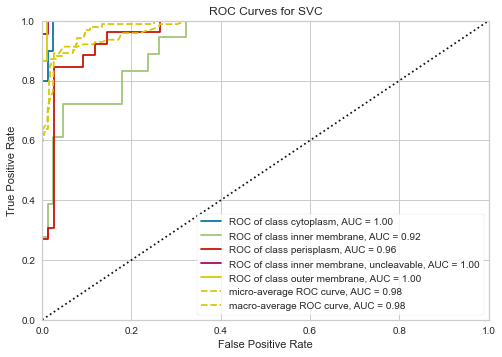

<AxesSubplot:title={'center':'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [18]:
visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()        

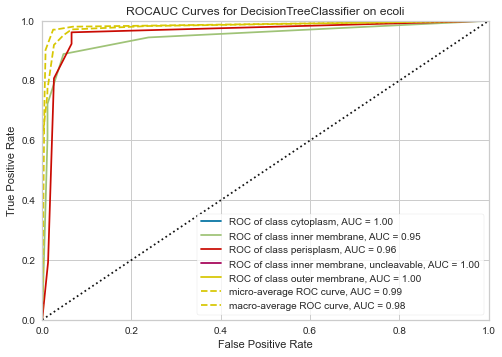

<AxesSubplot:title={'center':'ROCAUC Curves for DecisionTreeClassifier on ecoli'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [19]:
visualizer_1.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_1.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_1.show()        

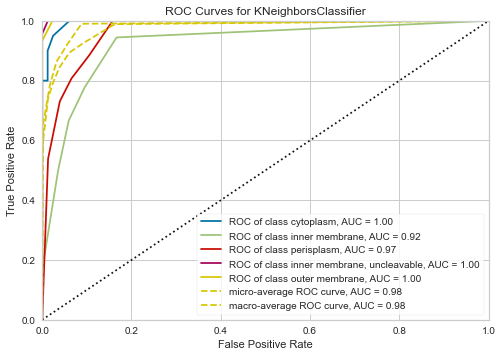

<AxesSubplot:title={'center':'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [20]:
visualizer_2.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_2.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_2.show()    